In [1]:
import os
import numpy as np
from PIL import Image
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
DATASET_DIR = "../planetsdataset"

TRAIN_DIR = os.path.join(DATASET_DIR, "training")
VALID_DIR = os.path.join(DATASET_DIR, "validation")
TEST_DIR = os.path.join(DATASET_DIR, "test")

In [4]:
CLASS_NAMES = sorted([
    folder_name
    for folder_name in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, folder_name))
])

print("Classes:", CLASS_NAMES)

Classes: ['asteroid', 'earth', 'galaxy', 'jupiter', 'mars', 'mercury', 'moon', 'neptune', 'pluto', 'saturn', 'uranus', 'venus']


In [5]:
def load_images_from_split(split_dir, class_names, img_size=(64, 64)):
    X = []
    y = []

    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(split_dir, class_name)

        if not os.path.isdir(class_dir):
            print(f"Warning: folder not found: {class_dir}")
            continue

        for file_name in os.listdir(class_dir):
            file_path = os.path.join(class_dir, file_name)

            try:
                img = Image.open(file_path).convert("RGB")
                img = img.resize(img_size)
                img_array = np.array(img, dtype=np.float32) / 255.0
                X.append(img_array.flatten())
                y.append(label)
            except Exception as e:
                print(f"Skipping {file_path}: {e}")

    return np.array(X), np.array(y)

In [6]:
IMG_SIZE = (64, 64)

X_train, y_train = load_images_from_split(TRAIN_DIR, CLASS_NAMES, IMG_SIZE)
print("train images loaded")
X_valid, y_valid = load_images_from_split(VALID_DIR, CLASS_NAMES, IMG_SIZE)
print("validation images loaded")
X_test, y_test = load_images_from_split(TEST_DIR, CLASS_NAMES, IMG_SIZE)
print("test images loaded")

train images loaded
validation images loaded
test images loaded


In [7]:
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2430, 12288) (2430,)
Validation: (666, 12288) (666,)
Test: (341, 12288) (341,)


In [8]:
model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=2000, n_jobs=-1, random_state=42)

In [9]:
y_valid_pred = model.predict(X_valid)

print("\nValidation Accuracy:", accuracy_score(y_valid, y_valid_pred))
print("\nValidation Report:")
print(classification_report(y_valid, y_valid_pred, target_names=CLASS_NAMES))


Validation Accuracy: 0.8408408408408409

Validation Report:
              precision    recall  f1-score   support

    asteroid       0.55      0.52      0.54        42
       earth       0.88      0.85      0.86        59
      galaxy       0.75      0.96      0.84        48
     jupiter       0.74      0.74      0.74        57
        mars       0.93      0.93      0.93        61
     mercury       0.81      0.88      0.84        57
        moon       0.73      0.72      0.73        57
     neptune       0.94      0.89      0.92        57
       pluto       0.82      0.81      0.81        57
      saturn       0.88      0.77      0.82        57
      uranus       1.00      0.98      0.99        57
       venus       0.98      0.96      0.97        57

    accuracy                           0.84       666
   macro avg       0.83      0.83      0.83       666
weighted avg       0.84      0.84      0.84       666



In [14]:
y_test_pred = model.predict(X_test)

print("\Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\Test Report:")
print(classification_report(y_test, y_test_pred, target_names=CLASS_NAMES))

\Test Accuracy: 0.8005865102639296
\Test Report:
              precision    recall  f1-score   support

    asteroid       0.64      0.55      0.59        29
       earth       0.92      0.76      0.83        29
      galaxy       0.67      0.97      0.79        29
     jupiter       0.69      0.64      0.67        28
        mars       0.88      0.97      0.92        30
     mercury       0.88      0.75      0.81        28
        moon       0.56      0.50      0.53        28
     neptune       0.93      0.93      0.93        28
       pluto       0.69      0.89      0.78        28
      saturn       0.85      0.82      0.84        28
      uranus       1.00      0.96      0.98        28
       venus       1.00      0.86      0.92        28

    accuracy                           0.80       341
   macro avg       0.81      0.80      0.80       341
weighted avg       0.81      0.80      0.80       341



In [11]:
import joblib
joblib.dump(model, "planet_classifier.joblib")

['planet_classifier.joblib']

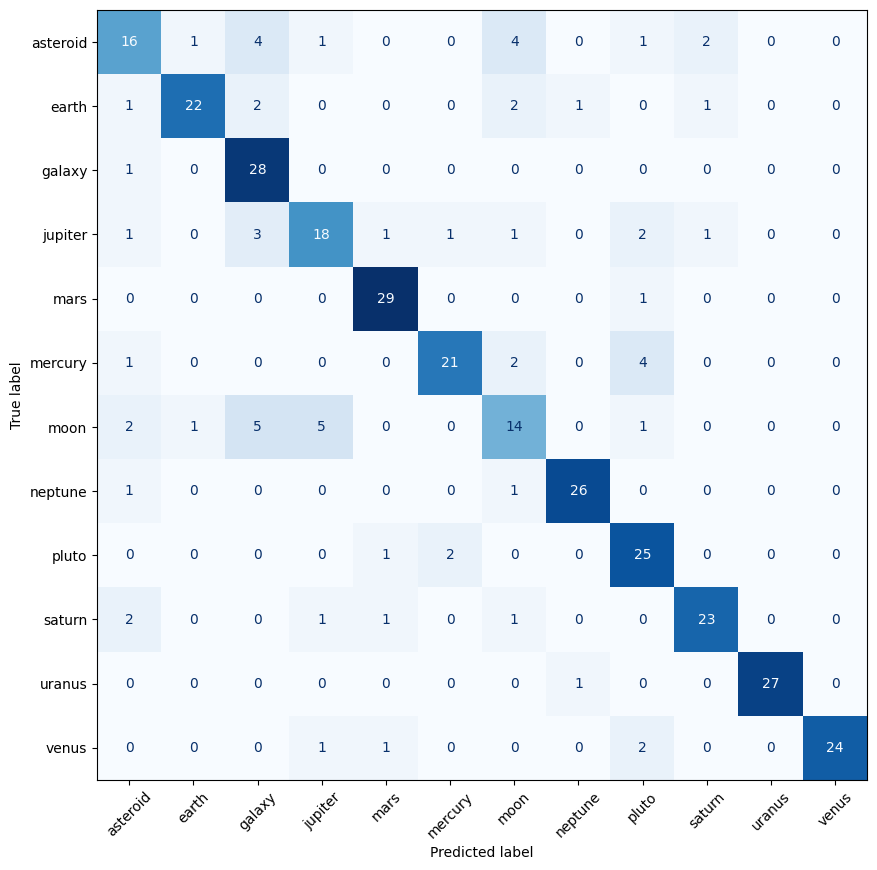

In [12]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.show()

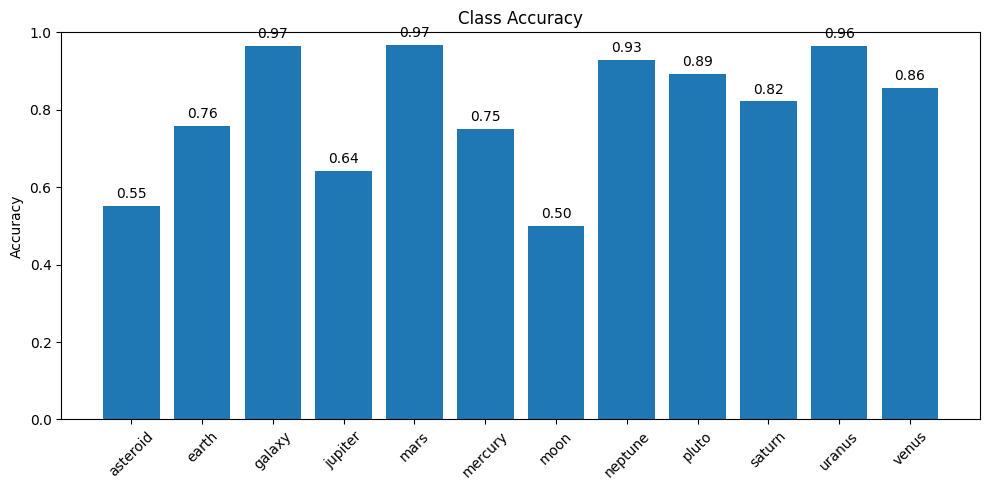

In [13]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 5))
plt.bar(CLASS_NAMES, per_class_accuracy)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Class Accuracy")
plt.xticks(rotation=45)

for i, acc in enumerate(per_class_accuracy):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha="center")

plt.tight_layout()
plt.show()